# 03 — EDA del Dataset Procesado

Análisis del output de `python -m src.features.pipeline`.

**Requiere**: `data/processed/*.npy` (correr el pipeline primero).

Secciones:
1. Carga y estadísticas básicas
2. Distribución de labels y balance
3. Distribución de features numéricas (post-scaling)
4. Correlación entre features
5. Separabilidad univariada
6. Box plots bivariados
7. Categorías y embeddings de texto
8. PCA del espacio numérico
9. Split temporal: distribución train/val
10. Resumen ejecutivo


In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

from src.features.categorical import CategoryEncoder
from src.features.numerical import NUMERICAL_FEATURE_NAMES

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})
PALETTE = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
PROCESSED = ROOT / 'data' / 'processed'
FIGURES = ROOT / 'figures'

assert PROCESSED.exists(), f'No existe {PROCESSED} — correr: python -m src.features.pipeline'
print('Procesado OK')


Procesado OK


## 1. Carga y estadísticas básicas

In [3]:
X = np.load(PROCESSED / 'numerical_features.npy')    # (N, 23)
y = np.load(PROCESSED / 'labels.npy')                # (N,)
C = np.load(PROCESSED / 'category_ids.npy')          # (N,)
T = np.load(PROCESSED / 'text_embeddings.npy')        # (N, 384)
E = np.load(PROCESSED / 'end_dates.npy')             # (N,) timestamps

N, F = X.shape
print(f'Samples:              {N:,}')
print(f'Features numéricas:   {F}  (esperado: 23)')
print(f'Categorías únicas:    {len(np.unique(C))}')
print(f'Dimensión embedding:  {T.shape[1]}')
print(f'Positivos (label=1):  {y.sum():.0f} ({100*y.mean():.1f}%)')
print(f'Negativos (label=0):  {(1-y).sum():.0f} ({100*(1-y).mean():.1f}%)')
print(f'Ratio pos/neg:        {y.sum()/(1-y).sum():.2f}')

Samples:              39,545
Features numéricas:   25  (esperado: 23)
Categorías únicas:    8
Dimensión embedding:  384
Positivos (label=1):  12357 (31.2%)
Negativos (label=0):  27188 (68.8%)
Ratio pos/neg:        0.45


## 2. Distribución de labels y balance

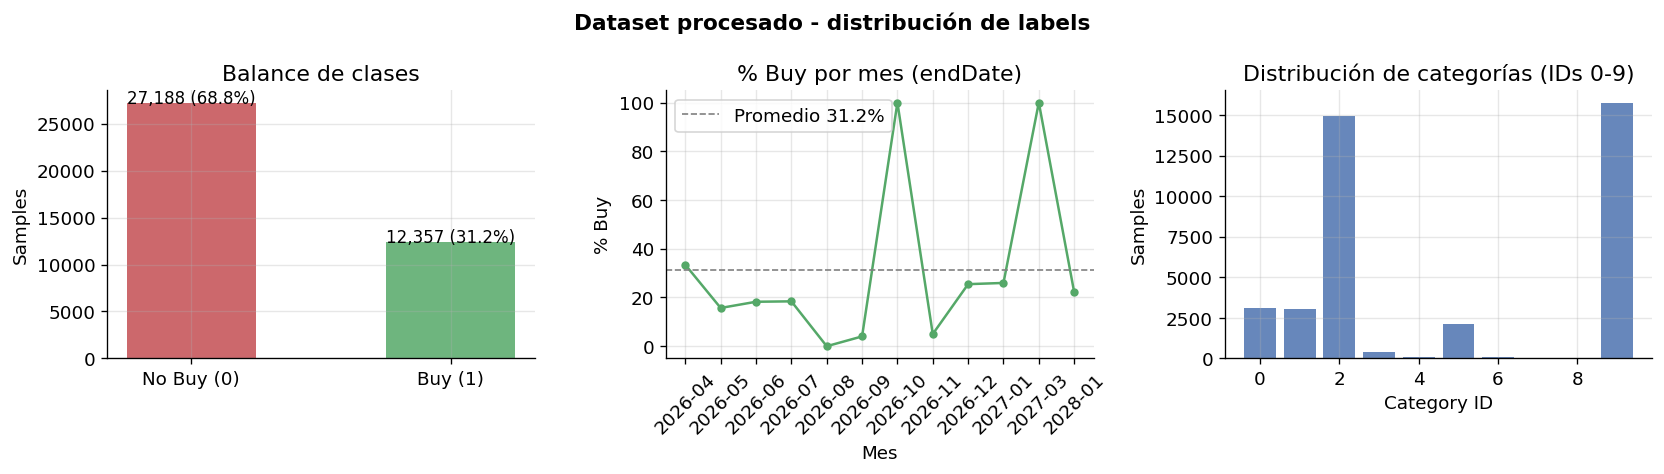

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax = axes[0]
counts = [int((y == 0).sum()), int((y == 1).sum())]
bars = ax.bar(['No Buy (0)', 'Buy (1)'], counts, color=[PALETTE[3], PALETTE[2]], alpha=0.85, width=0.5)
for bar, count in zip(bars, counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 20,
        f'{count:,} ({100 * count / N:.1f}%)',
        ha='center',
        fontsize=10,
    )
ax.set_title('Balance de clases')
ax.set_ylabel('Samples')

ax = axes[1]
if E.max() > 0:
    dates = pd.to_datetime(E, unit='s', utc=True)
    df_temp = pd.DataFrame({'date': dates, 'label': y})
    df_temp['month'] = df_temp['date'].dt.tz_localize(None).dt.to_period('M')
    monthly = df_temp.groupby('month')['label'].agg(['sum', 'count'])
    monthly['pct_buy'] = 100 * monthly['sum'] / monthly['count']
    ax.plot(monthly.index.astype(str), monthly['pct_buy'], color=PALETTE[2], marker='o', ms=4)
    ax.axhline(100 * y.mean(), color='gray', linestyle='--', lw=1, label=f'Promedio {100 * y.mean():.1f}%')
    ax.set_title('% Buy por mes (endDate)')
    ax.set_xlabel('Mes')
    ax.set_ylabel('% Buy')
    ax.legend()
    ax.tick_params(axis='x', rotation=45)
else:
    ax.text(0.5, 0.5, 'Sin timestamps', ha='center', va='center', transform=ax.transAxes)

ax = axes[2]
cat_counts = pd.Series(C).value_counts().sort_index()
ax.bar(cat_counts.index, cat_counts.values, color=PALETTE[0], alpha=0.85)
ax.set_title('Distribución de categorías (IDs 0-9)')
ax.set_xlabel('Category ID')
ax.set_ylabel('Samples')

plt.suptitle('Dataset procesado - distribución de labels', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'processed_labels.png', bbox_inches='tight')
plt.show()


## 3. Distribución de features numéricas (post-scaling)

Después del StandardScaler, cada feature debería tener media ~0 y std ~1.
Features con % de ceros alto son normales (e.g., order book en resueltos).

In [5]:
df_feat = pd.DataFrame(X, columns=NUMERICAL_FEATURE_NAMES)

# Estadísticas básicas
stats = df_feat.describe().T
stats['pct_zero'] = (df_feat == 0).mean() * 100
stats['pct_zero_str'] = stats['pct_zero'].round(1).astype(str) + '%'
print('=== Stats post-scaling ===')
print(stats[['mean','std','min','max','pct_zero_str']].round(3).to_string())

=== Stats post-scaling ===
                             mean  std     min      max pct_zero_str
snapshot_price_yes           -0.0  1.0  -1.077    1.917         0.0%
days_to_end                   0.0  1.0  -0.687    4.103         0.0%
market_age_days_at_snapshot   0.0  1.0  -0.414    7.109         0.0%
days_since_last_trade        -0.0  1.0  -0.291    8.341         0.0%
history_points_1d            -0.0  1.0  -0.980    1.659         0.0%
history_points_3d             0.0  1.0  -0.908    1.776         0.0%
history_points_7d             0.0  1.0  -0.959    1.987         0.0%
history_points_30d           -0.0  1.0  -0.749    3.671         0.0%
history_span_days            -0.0  1.0  -0.375    8.138         0.0%
return_1d                    -0.0  1.0  -1.032   84.796         0.0%
return_3d                    -0.0  1.0  -0.195  196.977         0.0%
return_7d                     0.0  1.0  -1.086   69.649         0.0%
return_14d                    0.0  1.0  -1.075   71.003         0.0%
return_

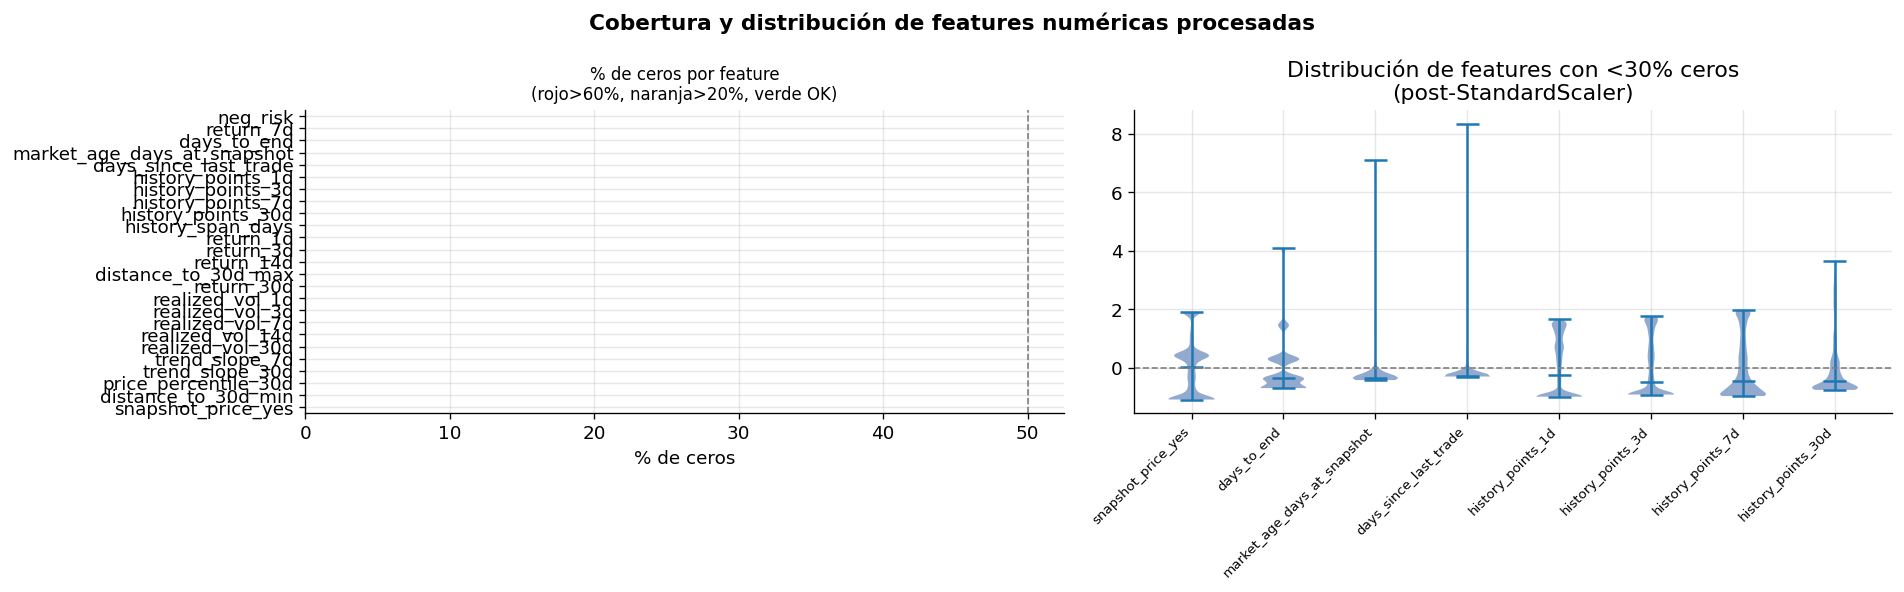

In [6]:
# % de ceros por feature
zero_pct = (df_feat == 0).mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
colors = ['#C44E52' if v > 60 else '#DD8452' if v > 20 else '#55A868' for v in zero_pct]
zero_pct.sort_values().plot.barh(ax=ax, color=colors, alpha=0.85)
ax.axvline(50, color='gray', linestyle='--', lw=1)
ax.set_title('% de ceros por feature\n(rojo>60%, naranja>20%, verde OK)', fontsize=10)
ax.set_xlabel('% de ceros')

# Distribuciones (violin) de features con pocos ceros
ax = axes[1]
low_zero = zero_pct[zero_pct < 30].index.tolist()[:8]
if low_zero:
    data_plot = [df_feat[c].values for c in low_zero]
    vp = ax.violinplot(data_plot, positions=range(len(low_zero)), showmedians=True)
    for body in vp['bodies']:
        body.set_facecolor(PALETTE[0])
        body.set_alpha(0.6)
    ax.set_xticks(range(len(low_zero)))
    ax.set_xticklabels(low_zero, rotation=45, ha='right', fontsize=8)
    ax.set_title('Distribución de features con <30% ceros\n(post-StandardScaler)')
    ax.axhline(0, color='gray', linestyle='--', lw=1)

plt.suptitle('Cobertura y distribución de features numéricas procesadas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'processed_feature_distributions.png', bbox_inches='tight')
plt.show()

## 4. Correlación entre features

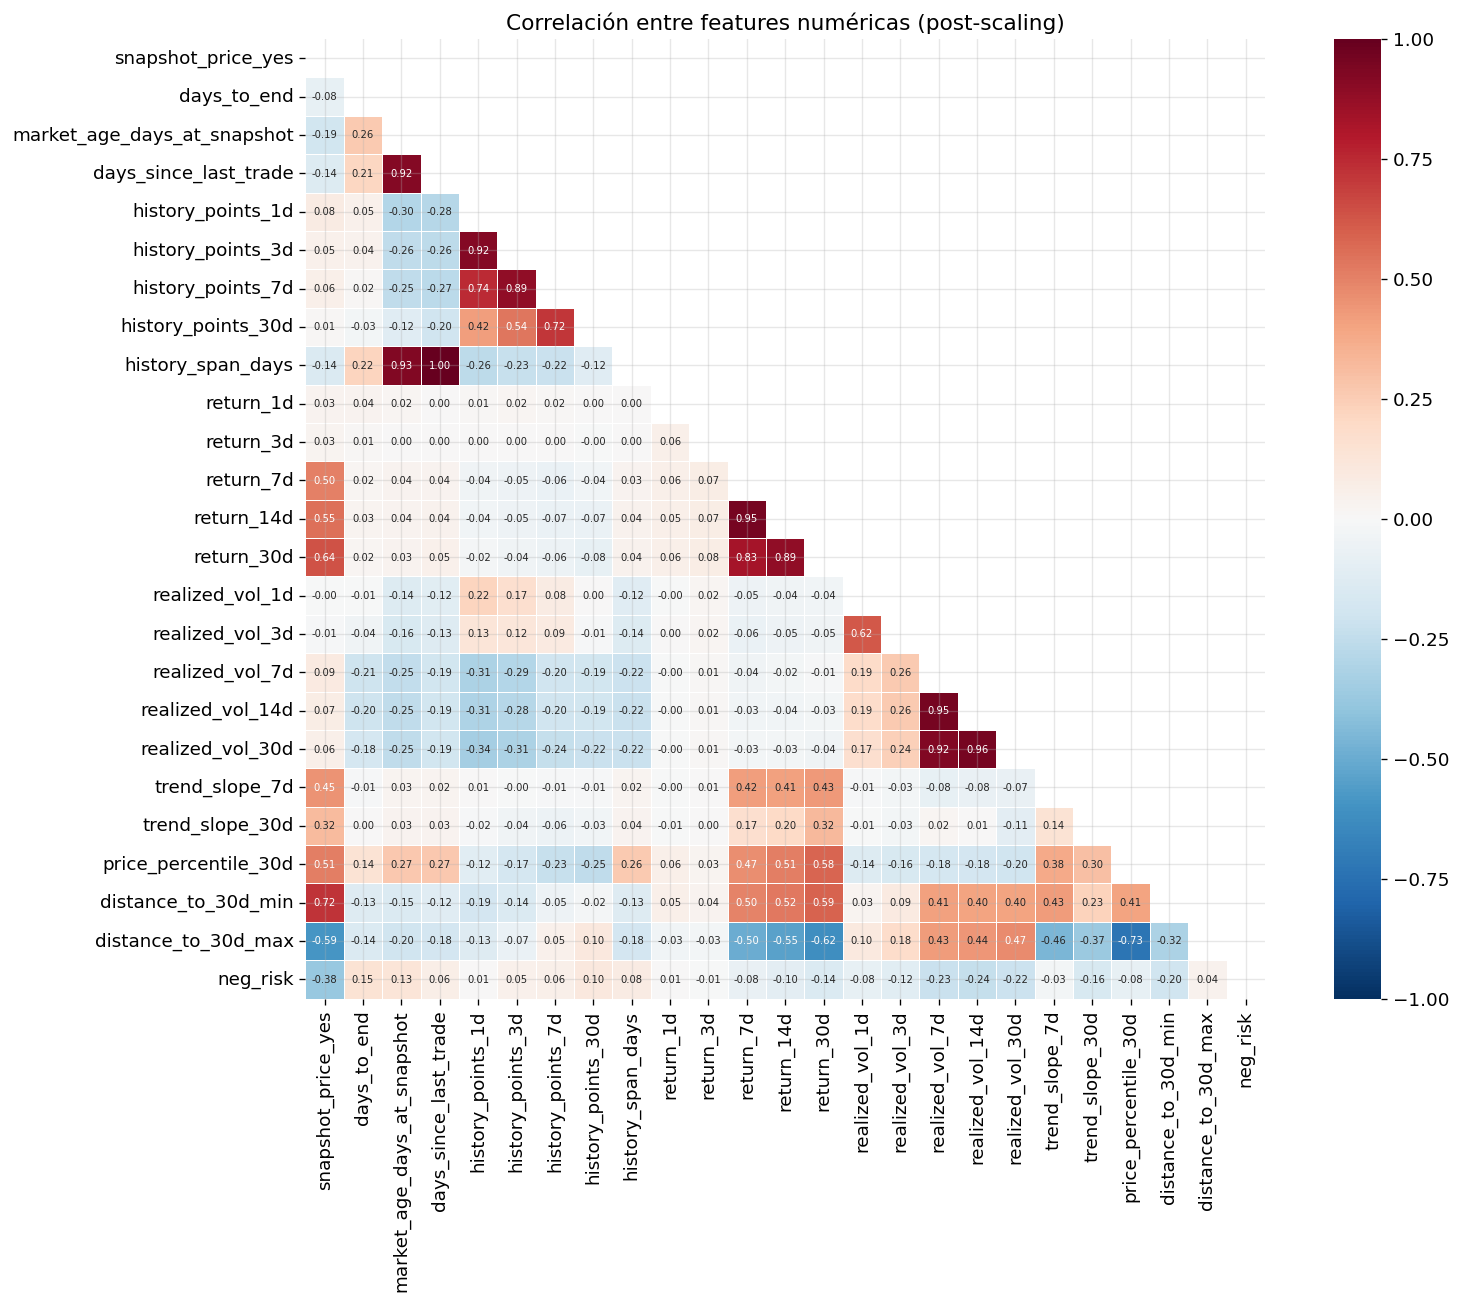

Correlaciones altas (|r|>0.5):
  history_span_days              x days_since_last_trade         : +1.00
  realized_vol_30d               x realized_vol_14d              : +0.96
  realized_vol_14d               x realized_vol_7d               : +0.95
  return_14d                     x return_7d                     : +0.95
  history_span_days              x market_age_days_at_snapshot   : +0.93
  realized_vol_30d               x realized_vol_7d               : +0.92
  days_since_last_trade          x market_age_days_at_snapshot   : +0.92
  history_points_3d              x history_points_1d             : +0.92
  return_30d                     x return_14d                    : +0.89
  history_points_7d              x history_points_3d             : +0.89


In [7]:
corr = df_feat.corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1, ax=ax,
    annot_kws={'size': 6}, linewidths=0.3, square=True,
)
ax.set_title('Correlación entre features numéricas (post-scaling)', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES / 'processed_correlation.png', bbox_inches='tight')
plt.show()

# Pares más correlacionados
corr_upper = corr.where(~mask & (corr.abs() > 0.5))
print('Correlaciones altas (|r|>0.5):')
pairs = corr_upper.stack().sort_values(key=abs, ascending=False)
for (a, b), v in pairs.head(10).items():
    print(f'  {a:30s} x {b:30s}: {v:+.2f}')

## 5. Separabilidad: ¿discriminan las features entre Buy y No Buy?

Para cada feature, calculamos el AUC-ROC univariado. Una feature perfecta tendría AUC=1.0; una inútil AUC=0.5.


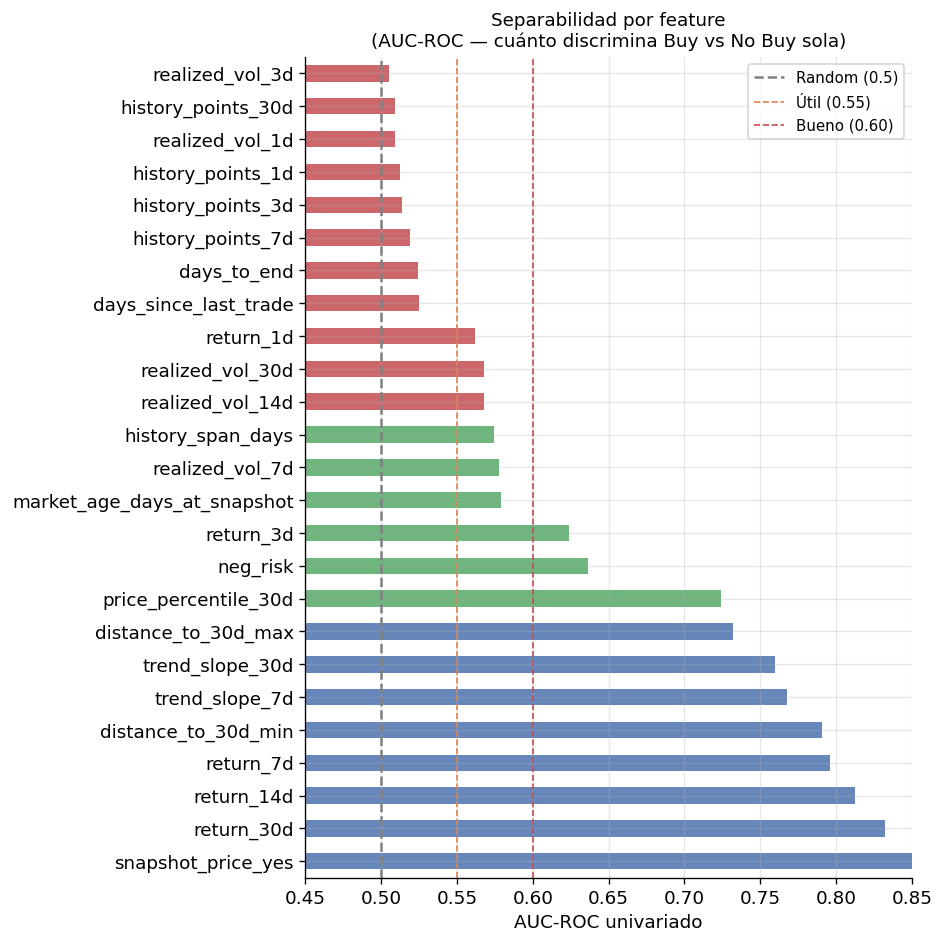

Top features (AUC):
  snapshot_price_yes            : 0.905 ████████████████████████████████████████
  return_30d                    : 0.832 █████████████████████████████████
  return_14d                    : 0.813 ███████████████████████████████
  return_7d                     : 0.796 █████████████████████████████
  distance_to_30d_min           : 0.791 █████████████████████████████
  trend_slope_7d                : 0.767 ██████████████████████████
  trend_slope_30d               : 0.760 █████████████████████████
  distance_to_30d_max           : 0.732 ███████████████████████
  price_percentile_30d          : 0.724 ██████████████████████
  neg_risk                      : 0.636 █████████████


In [8]:
from sklearn.metrics import roc_auc_score

aucs = []
for i, name in enumerate(NUMERICAL_FEATURE_NAMES):
    col = X[:, i]
    if col.std() == 0 or len(np.unique(col)) < 2:
        aucs.append(0.5)
        continue
    try:
        auc = roc_auc_score(y, col)
        auc = max(auc, 1 - auc)  # tomar el mayor entre AUC y 1-AUC
    except Exception:
        auc = 0.5
    aucs.append(auc)

auc_series = pd.Series(aucs, index=NUMERICAL_FEATURE_NAMES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
colors = ['#C44E52' if v > 0.6 else '#55A868' if v > 0.55 else '#4C72B0' for v in auc_series]
auc_series.plot.barh(ax=ax, color=colors[::-1], alpha=0.85)
ax.axvline(0.5, color='gray', linestyle='--', lw=1.5, label='Random (0.5)')
ax.axvline(0.55, color='#DD8452', linestyle='--', lw=1, label='Útil (0.55)')
ax.axvline(0.6, color='#C44E52', linestyle='--', lw=1, label='Bueno (0.60)')
ax.set_xlabel('AUC-ROC univariado')
ax.set_title('Separabilidad por feature\n(AUC-ROC — cuánto discrimina Buy vs No Buy sola)', fontsize=11)
ax.legend(fontsize=9)
ax.set_xlim(0.45, 0.85)
plt.tight_layout()
plt.savefig(FIGURES / 'processed_feature_auc.png', bbox_inches='tight')
plt.show()

print('Top features (AUC):')
for name, auc in auc_series.head(10).items():
    bar = '█' * int((auc - 0.5) * 100)
    print(f'  {name:30s}: {auc:.3f} {bar}')


## 6. Box plots bivariados: features vs label


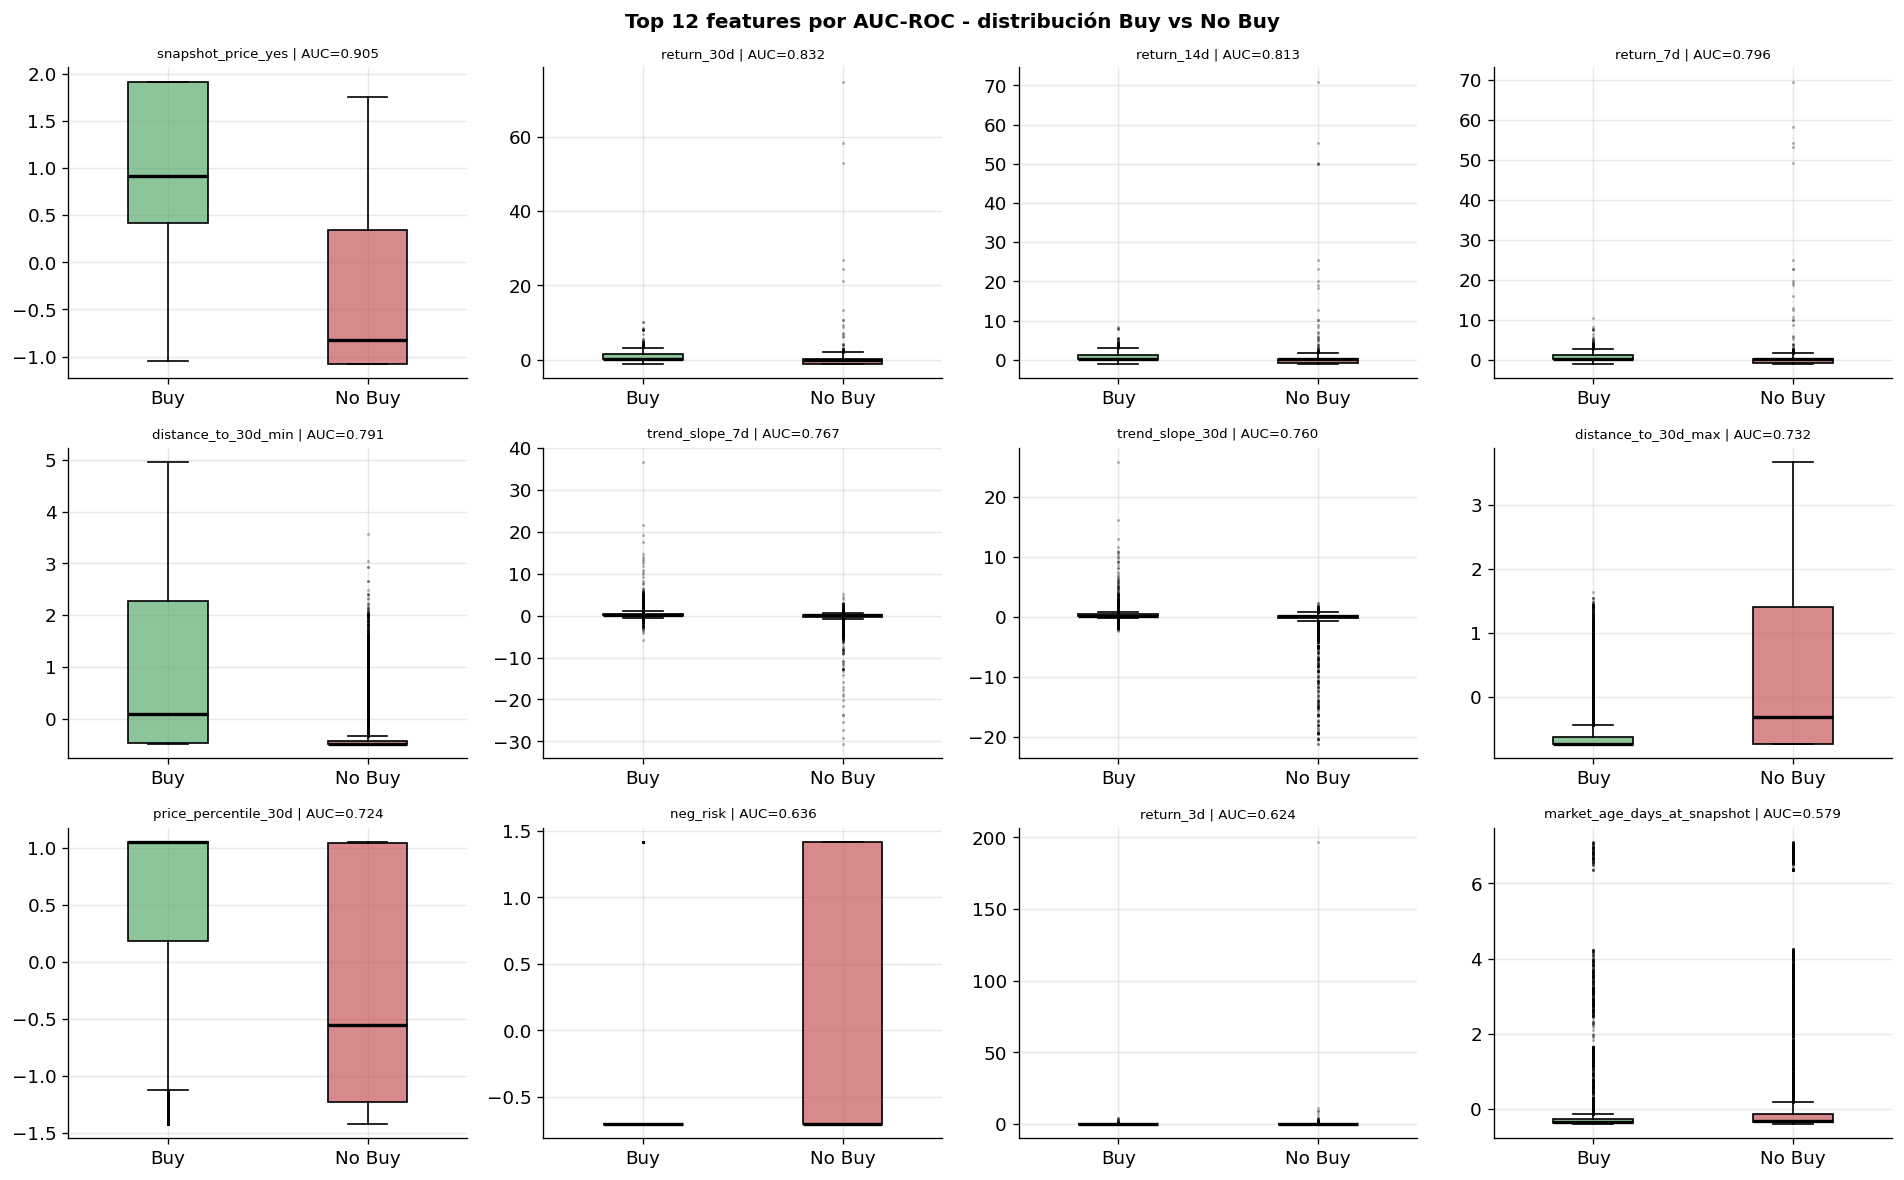

In [9]:
# Top 12 features por AUC para box plots
top_features = auc_series.head(12).index.tolist()

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for ax, feat in zip(axes, top_features):
    i = NUMERICAL_FEATURE_NAMES.index(feat)
    buy_v = X[y == 1, i]
    no_buy_v = X[y == 0, i]
    if 'momentum' in feat or 'volatility' in feat or 'trend' in feat or 'ewm' in feat:
        buy_v = buy_v[buy_v != 0]
        no_buy_v = no_buy_v[no_buy_v != 0]
    if len(buy_v) < 5 or len(no_buy_v) < 5:
        ax.set_visible(False)
        continue
    bp = ax.boxplot(
        [buy_v, no_buy_v],
        patch_artist=True,
        medianprops={'color': 'black', 'lw': 2},
        flierprops={'marker': '.', 'markersize': 1.5, 'alpha': 0.3},
        widths=0.4,
    )
    bp['boxes'][0].set_facecolor(PALETTE[2] + 'AA')
    bp['boxes'][1].set_facecolor(PALETTE[3] + 'AA')
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Buy', 'No Buy'])
    ax.set_title(f'{feat} | AUC={auc_series[feat]:.3f}', fontsize=8)

for ax in axes[len(top_features):]:
    ax.set_visible(False)

plt.suptitle('Top 12 features por AUC-ROC - distribución Buy vs No Buy', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'processed_bivariate_top.png', bbox_inches='tight')
plt.show()


## 7. Categorías y embeddings de texto

Aquí revisamos dos piezas no numéricas del dataset procesado:
- la distribución real de categorías inferidas por el encoder
- la geometría básica de los embeddings de `question`


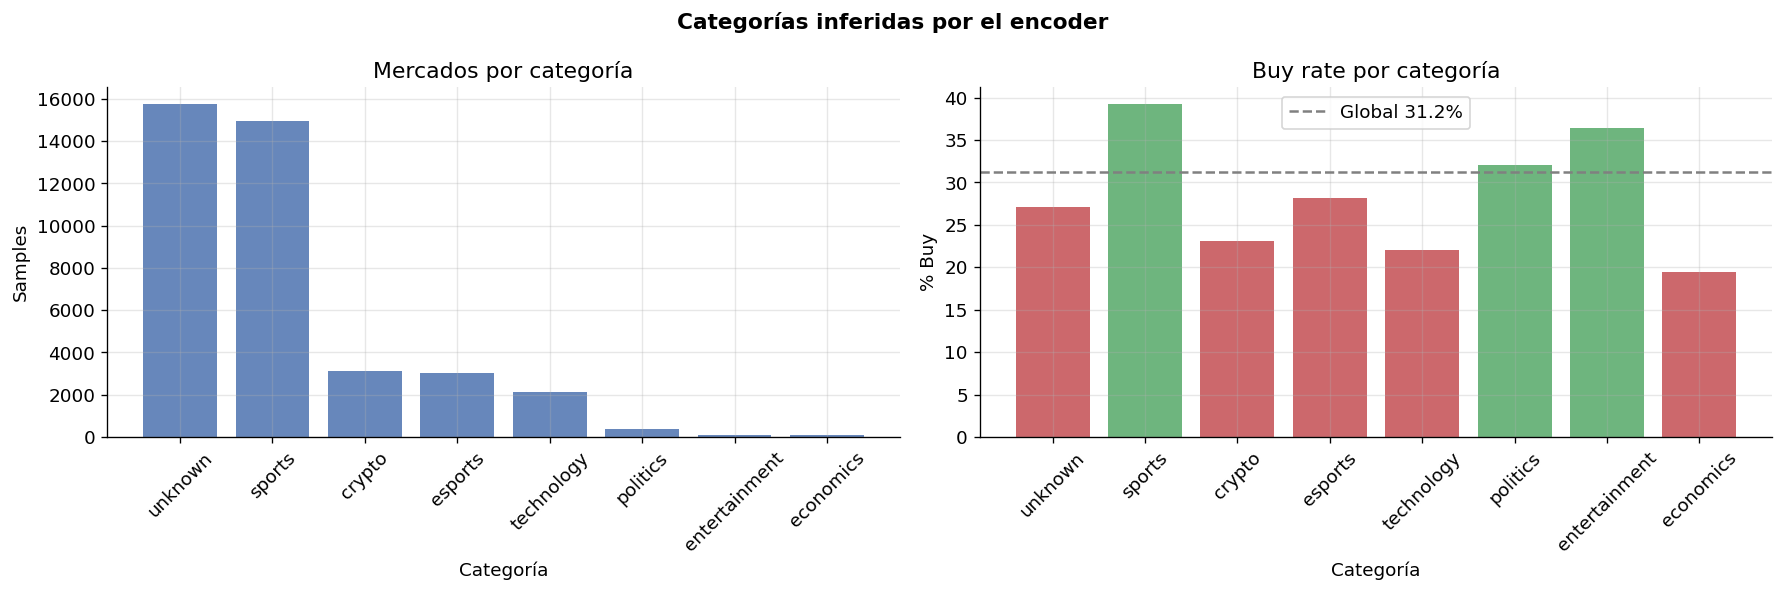

Resumen categorías:
                   n  buy_rate_pct
category                          
unknown        15755     27.100000
sports         14950     39.240002
crypto          3107     23.139999
esports         3027     28.209999
technology      2143     22.070000
politics         390     32.049999
entertainment     96     36.459999
economics         77     19.480000


In [10]:
encoder_path = PROCESSED / 'pipeline' / 'category_encoder.json'
cat_encoder = CategoryEncoder.load(str(encoder_path)) if encoder_path.exists() else CategoryEncoder()
cat_names = [cat_encoder.id_to_cat.get(int(cat_id), 'unknown') for cat_id in C]

df_cat = pd.DataFrame({'category': cat_names, 'label': y})
cat_stats = (
    df_cat.groupby('category')['label']
    .agg(n='size', buy_rate='mean')
    .sort_values('n', ascending=False)
)
cat_stats['buy_rate_pct'] = 100 * cat_stats['buy_rate']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
ax.bar(cat_stats.index, cat_stats['n'], color=PALETTE[0], alpha=0.85)
ax.set_title('Mercados por categoría')
ax.set_xlabel('Categoría')
ax.set_ylabel('Samples')
ax.tick_params(axis='x', rotation=45)

ax = axes[1]
colors = [PALETTE[2] if val >= 100 * y.mean() else PALETTE[3] for val in cat_stats['buy_rate_pct']]
ax.bar(cat_stats.index, cat_stats['buy_rate_pct'], color=colors, alpha=0.85)
ax.axhline(100 * y.mean(), color='gray', linestyle='--', lw=1.5, label=f'Global {100 * y.mean():.1f}%')
ax.set_title('Buy rate por categoría')
ax.set_xlabel('Categoría')
ax.set_ylabel('% Buy')
ax.tick_params(axis='x', rotation=45)
ax.legend()

plt.suptitle('Categorías inferidas por el encoder', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'processed_categories.png', bbox_inches='tight')
plt.show()

print('Resumen categorías:')
print(cat_stats[['n', 'buy_rate_pct']].round(2).to_string())


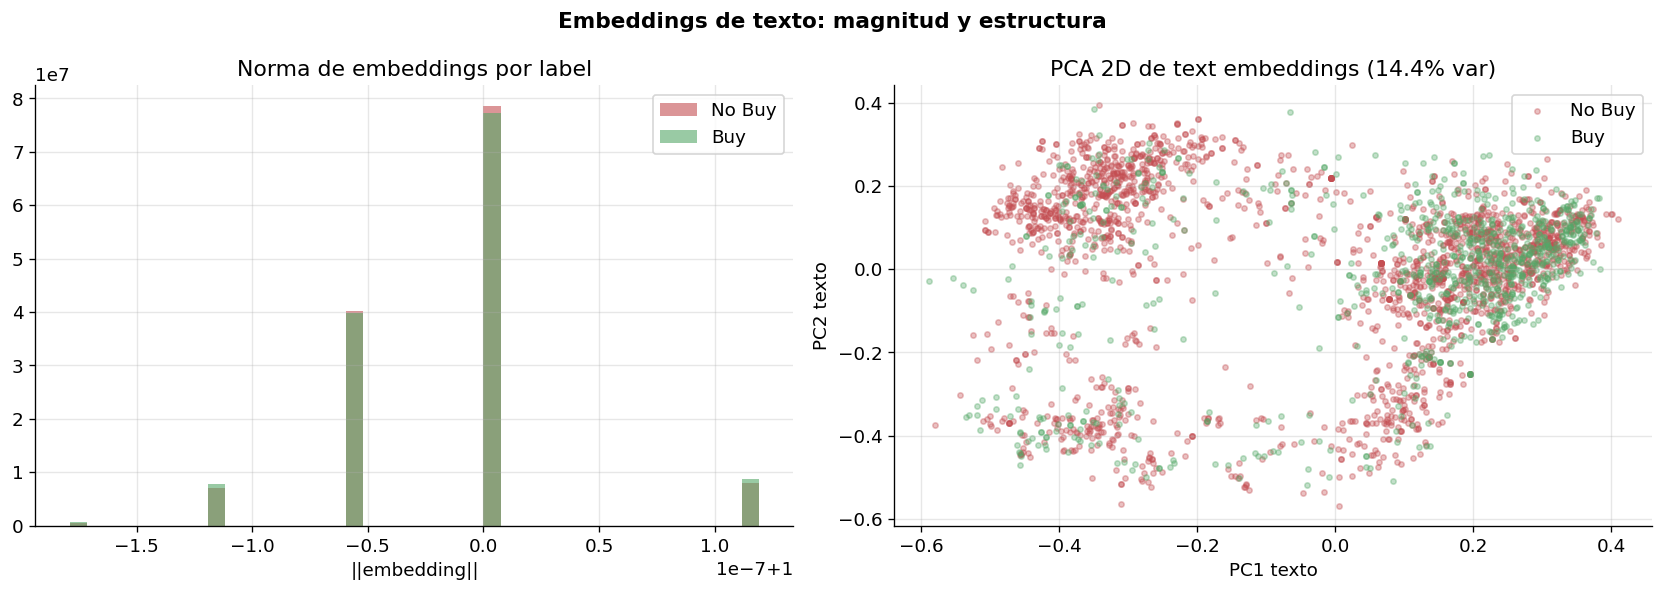

Norma embedding - mean: 1.000, std: 0.000
PCA 2D sobre embeddings explica 14.4% de la varianza en la muestra.


In [11]:
emb_norm = np.linalg.norm(T, axis=1)
max_points = min(3000, len(T))
rng = np.random.default_rng(42)
idx = rng.choice(len(T), size=max_points, replace=False) if len(T) > max_points else np.arange(len(T))
T_sample = T[idx]
y_sample = y[idx]
label_specs = [(0, PALETTE[3], 'No Buy'), (1, PALETTE[2], 'Buy')]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
norm_range = float(np.ptp(emb_norm))
if norm_range < 1e-9:
    center = float(emb_norm.mean()) if len(emb_norm) else 0.0
    pad = max(1e-3, abs(center) * 0.05, 0.1)
    for label, color, name in label_specs:
        subset = emb_norm[y == label]
        if len(subset):
            ax.axvline(float(subset.mean()), color=color, lw=2.5, alpha=0.9, label=f'{name} ({len(subset):,})')
    ax.set_xlim(center - pad, center + pad)
    ax.text(0.5, 0.92, 'Norma casi constante;\nse muestran medias por label', ha='center', va='top', transform=ax.transAxes, fontsize=10)
else:
    n_bins = min(40, max(10, int(np.sqrt(len(emb_norm)))))
    bins = np.linspace(float(emb_norm.min()), float(emb_norm.max()), n_bins + 1)
    for label, color, name in label_specs:
        subset = emb_norm[y == label]
        if len(subset):
            ax.hist(subset, bins=bins, alpha=0.6, color=color, label=name, density=True)
ax.set_title('Norma de embeddings por label')
ax.set_xlabel('||embedding||')
ax.legend()

ax = axes[1]
sample_var = float(np.max(np.var(T_sample, axis=0))) if len(T_sample) else 0.0
if len(T_sample) < 2 or sample_var < 1e-12:
    explained_text = 0.0
    embedding_note = 'Embeddings casi constantes en la muestra; PCA 2D no es informativa.'
    ax.text(0.5, 0.5, embedding_note, ha='center', va='center', wrap=True, fontsize=11)
    ax.set_axis_off()
else:
    text_pca = PCA(n_components=2)
    T_pca = text_pca.fit_transform(T_sample)
    explained_text = 100 * text_pca.explained_variance_ratio_.sum()
    embedding_note = f'PCA 2D sobre embeddings explica {explained_text:.1f}% de la varianza en la muestra.'
    for label, color, name in label_specs:
        mask = y_sample == label
        ax.scatter(T_pca[mask, 0], T_pca[mask, 1], c=color, alpha=0.35, s=10, label=name)
    ax.set_title(f'PCA 2D de text embeddings ({explained_text:.1f}% var)')
    ax.set_xlabel('PC1 texto')
    ax.set_ylabel('PC2 texto')
    ax.legend()

plt.suptitle('Embeddings de texto: magnitud y estructura', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'processed_text_embeddings.png', bbox_inches='tight')
plt.show()

print(f'Norma embedding - mean: {emb_norm.mean():.3f}, std: {emb_norm.std():.3f}')
if norm_range < 1e-9:
    print('Las normas de embeddings son casi constantes; el histograma se reemplazó por referencias por label.')
print(embedding_note)


## 8. PCA — visualización del espacio de features numéricas


Features con >5% no-cero: 25


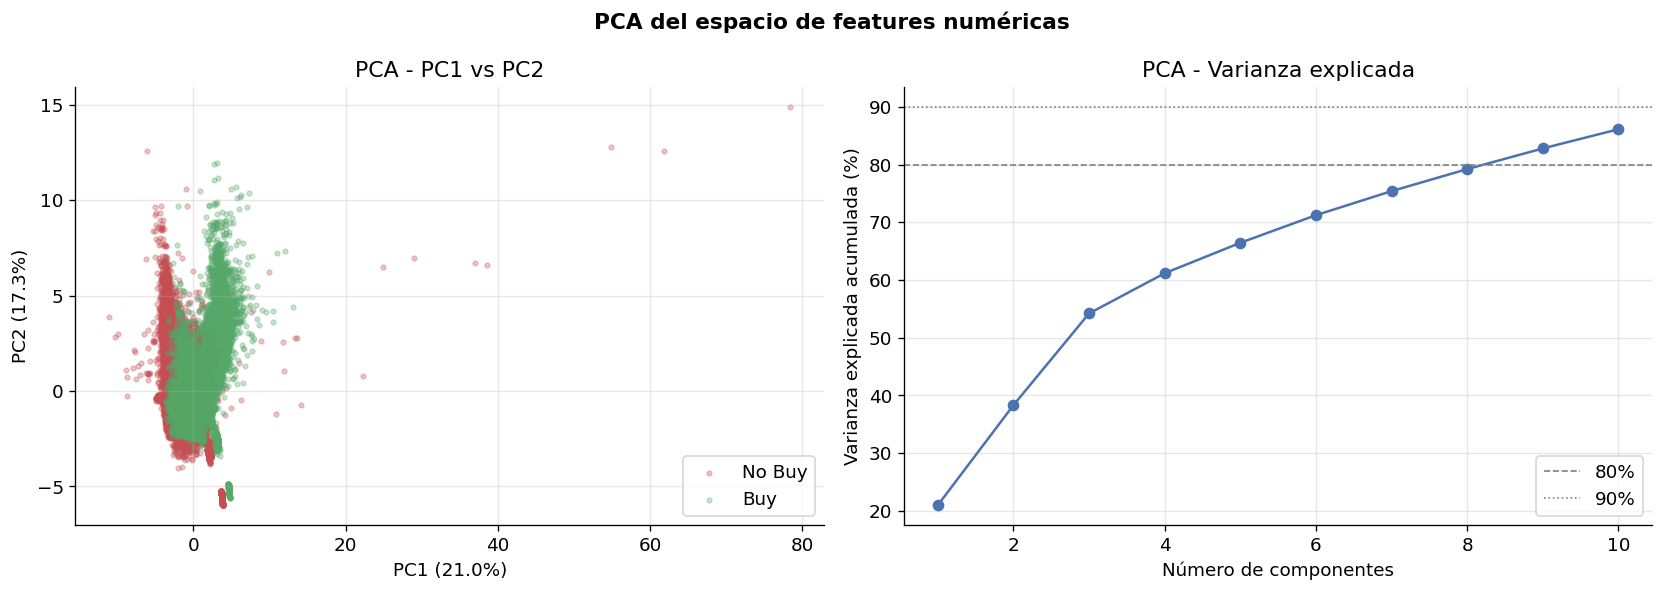

Varianza por componente:
  PC1: 21.0%
  PC2: 17.3%
  PC3: 15.9%
  PC4: 7.0%
  PC5: 5.3%


In [12]:
# PCA con las features que no son todas cero
non_zero_cols = [
    i for i, name in enumerate(NUMERICAL_FEATURE_NAMES)
    if (X[:, i] != 0).mean() > 0.05
]
X_nz = X[:, non_zero_cols]
print(f'Features con >5% no-cero: {len(non_zero_cols)}')

pca = PCA(n_components=min(10, len(non_zero_cols)))
X_pca = pca.fit_transform(X_nz)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for label, color, name in [(0, PALETTE[3], 'No Buy'), (1, PALETTE[2], 'Buy')]:
    mask_l = y == label
    ax.scatter(X_pca[mask_l, 0], X_pca[mask_l, 1], c=color, alpha=0.3, s=8, label=name)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)')
ax.set_title('PCA - PC1 vs PC2')
ax.legend()

ax = axes[1]
cum_var = np.cumsum(pca.explained_variance_ratio_) * 100
ax.plot(range(1, len(cum_var) + 1), cum_var, marker='o', color=PALETTE[0])
ax.axhline(80, color='gray', linestyle='--', lw=1, label='80%')
ax.axhline(90, color='gray', linestyle=':', lw=1, label='90%')
ax.set_xlabel('Número de componentes')
ax.set_ylabel('Varianza explicada acumulada (%)')
ax.set_title('PCA - Varianza explicada')
ax.legend()

plt.suptitle('PCA del espacio de features numéricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'processed_pca.png', bbox_inches='tight')
plt.show()

print('Varianza por componente:')
for i, value in enumerate(pca.explained_variance_ratio_[:5], 1):
    print(f'  PC{i}: {value * 100:.1f}%')


## 9. Split temporal — distribución de train vs val


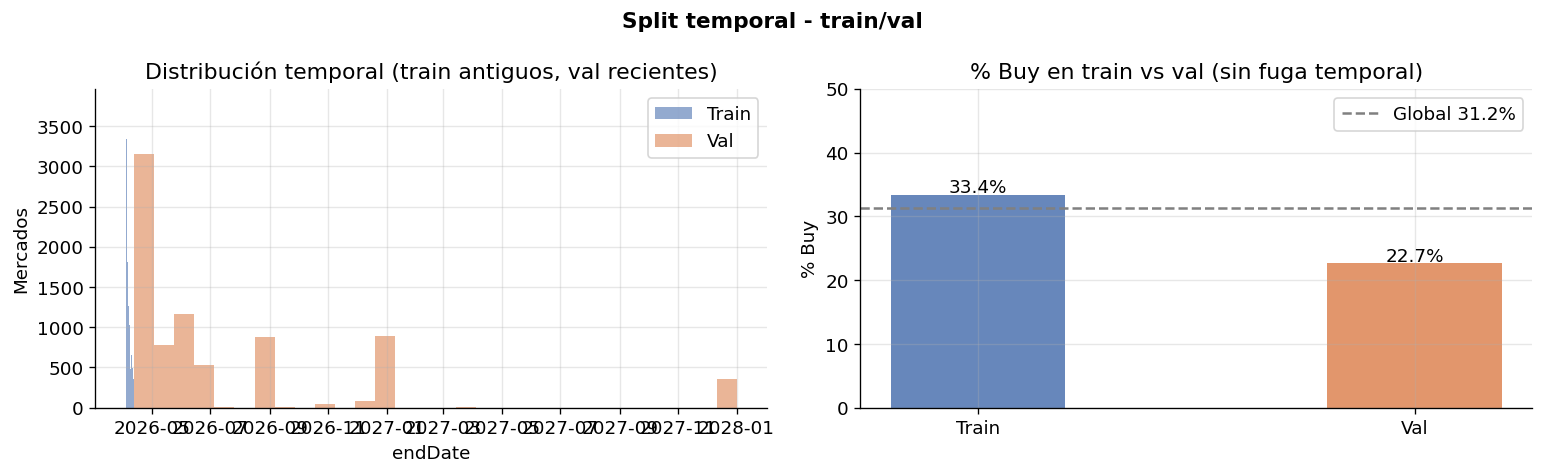

Train: 31,636 samples | 33.4% Buy
Val:   7,909 samples  | 22.7% Buy


In [13]:
if E.max() > 0:
    n = len(y)
    n_val = int(n * 0.2)
    sorted_idx = np.argsort(E)
    train_idx = sorted_idx[: n - n_val]
    val_idx = sorted_idx[n - n_val :]

    y_train = y[train_idx]
    y_val = y[val_idx]
    dates_all = pd.to_datetime(E, unit='s', utc=True)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    ax = axes[0]
    ax.hist(dates_all[train_idx], bins=30, alpha=0.6, color=PALETTE[0], label='Train')
    ax.hist(dates_all[val_idx], bins=30, alpha=0.6, color=PALETTE[1], label='Val')
    ax.set_title('Distribución temporal (train antiguos, val recientes)')
    ax.set_xlabel('endDate')
    ax.set_ylabel('Mercados')
    ax.legend()

    ax = axes[1]
    pos_rates = [100 * y_train.mean(), 100 * y_val.mean()]
    ax.bar(['Train', 'Val'], pos_rates, color=[PALETTE[0], PALETTE[1]], alpha=0.85, width=0.4)
    ax.axhline(100 * y.mean(), color='gray', linestyle='--', lw=1.5, label=f'Global {100 * y.mean():.1f}%')
    for idx, rate in enumerate(pos_rates):
        ax.text(idx, rate + 0.3, f'{rate:.1f}%', ha='center')
    ax.set_ylabel('% Buy')
    ax.set_title('% Buy en train vs val (sin fuga temporal)')
    ax.legend()
    ax.set_ylim(0, 50)

    plt.suptitle('Split temporal - train/val', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIGURES / 'processed_temporal_split.png', bbox_inches='tight')
    plt.show()

    print(f'Train: {len(train_idx):,} samples | {100 * y_train.mean():.1f}% Buy')
    print(f'Val:   {len(val_idx):,} samples  | {100 * y_val.mean():.1f}% Buy')
else:
    print('No hay timestamps disponibles para split temporal')


## 10. Resumen ejecutivo del dataset procesado


In [14]:
print('=' * 60)
print('RESUMEN DEL DATASET PROCESADO')
print('=' * 60)
print()
print(f'Samples totales:        {N:,}')
print(f'Features numéricas:     {F}')
print(f'Positivos (Buy):        {int(y.sum()):,} ({100 * y.mean():.1f}%)')
print(f'Negativos (No Buy):     {int((1 - y).sum()):,} ({100 * (1 - y).mean():.1f}%)')

zero_heavy = [
    (name, pct)
    for name, pct in zip(NUMERICAL_FEATURE_NAMES, (X == 0).mean(axis=0) * 100)
    if pct > 50
]
print()
print(f'Features con >50% ceros: {len(zero_heavy)}')
for name, pct in sorted(zero_heavy, key=lambda item: -item[1]):
    print(f'  {name}: {pct:.1f}%')

print()
print('Top 5 features por AUC-ROC univariado:')
for name, auc in auc_series.head(5).items():
    print(f'  {name}: {auc:.3f}')

print()
print('Categorías con más cobertura:')
for cat, row in cat_stats.head(5).iterrows():
    print(f"  {cat:15s}: {int(row['n']):,} samples | {row['buy_rate_pct']:.1f}% Buy")

print()
print('Notas para el modelo:')
print('  - neg_risk tiene alta separabilidad (confirmar con AUC arriba)')
print('  - Features TS útiles solo donde hay price_history (coverage ~70-80%)')
print('  - Las categorías tienen buy rates heterogéneos; conviene conservar embedding categórico')
print(f'  - {embedding_note}')
print('  - Split temporal: train=mercados viejos, val=mercados recientes')
print('=' * 60)


RESUMEN DEL DATASET PROCESADO

Samples totales:        39,545
Features numéricas:     25
Positivos (Buy):        12,357 (31.2%)
Negativos (No Buy):     27,188 (68.8%)

Features con >50% ceros: 0

Top 5 features por AUC-ROC univariado:
  snapshot_price_yes: 0.905
  return_30d: 0.832
  return_14d: 0.813
  return_7d: 0.796
  distance_to_30d_min: 0.791

Categorías con más cobertura:
  unknown        : 15,755 samples | 27.1% Buy
  sports         : 14,950 samples | 39.2% Buy
  crypto         : 3,107 samples | 23.1% Buy
  esports        : 3,027 samples | 28.2% Buy
  technology     : 2,143 samples | 22.1% Buy

Notas para el modelo:
  - neg_risk tiene alta separabilidad (confirmar con AUC arriba)
  - Features TS útiles solo donde hay price_history (coverage ~70-80%)
  - Las categorías tienen buy rates heterogéneos; conviene conservar embedding categórico
  - PCA 2D sobre embeddings explica 14.4% de la varianza en la muestra.
  - Split temporal: train=mercados viejos, val=mercados recientes
